In [15]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [16]:
class ModerationState(TypedDict):
    post_content: str
    user_reputation: str
    
    formatted_post: str
    content_flag: str
    result: str

In [17]:
def format_post(state: ModerationState):
    formatted = f"User ({state['user_reputation']}) says: {state['post_content']}"
    return {'formatted_post': formatted}

In [18]:
def analyse_content(state: ModerationState):
    content = state['post_content'].lower()
    
    if 'spam' in content or 'buy now' in content:
        flag = 'rejected'
    elif state['user_reputation'] == 'new_user':
        flag = 'review'
    else:
        flag = 'approved'
        
    return {'content_flag': flag}

In [19]:
def approve_post(state:ModerationState):
    result = "Post published successfully"
    return {
        "result" : result
        }

In [20]:
def flag_for_review(state:ModerationState):
    result = "post sent to human moderation queue"
    return {
        "result" : result
    }

In [21]:
def reject_post(state:ModerationState):
    result = "post automatically deleted due to policy voilation"
    return{
        "result" : result
    }

In [32]:
def check_condition(state:ModerationState) -> Literal["approve", "flag_for_review", "reject_post"]:
    if state["content_flag"] == "approved":
        return "approve_post"
    elif state["content_flag"] == "review":
        return "flag_for_review"
    else:
        return "reject_post"

In [33]:
graph = StateGraph(ModerationState)

graph.add_node("format_post", format_post)
graph.add_node("analyse_content", analyse_content)
graph.add_node("approve",approve_post)
graph.add_node("flag_for_review",flag_for_review)
graph.add_node("reject_post",reject_post)

graph.add_edge(START, "format_post")
graph.add_edge("format_post", "analyse_content")

graph.add_conditional_edges("analyse_content", check_condition)

graph.add_edge("approve", END)
graph.add_edge("flag_for_review", END)
graph.add_edge("reject_post", END)

workflow = graph.compile()

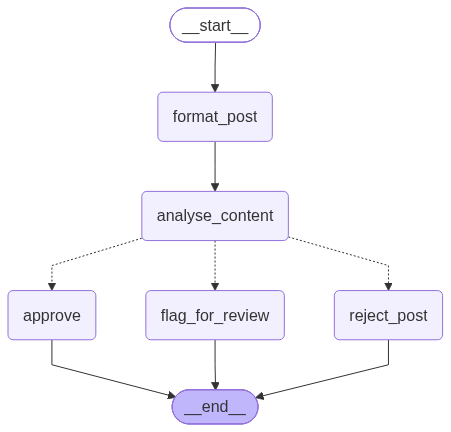

In [34]:
workflow

In [35]:
initial_state = {
    'post_content': "Check out this amazing new product!", 
    'user_reputation': "new_user"
}

result = workflow.invoke(initial_state)

In [36]:
result

{'post_content': 'Check out this amazing new product!',
 'user_reputation': 'new_user',
 'formatted_post': 'User (new_user) says: Check out this amazing new product!',
 'content_flag': 'review',
 'result': 'post sent to human moderation queue'}